In [21]:
import numpy as np
import pandas as pd

# Preprocessing

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from pathlib import Path

# ---------- Paths ----------
raw_csv_path = '/content/Ninapro_DB1.csv'
base_dir = Path('/content/drive/MyDrive/EMG_Project')
raw_dir = base_dir / 'raw'
processed_dir = base_dir / 'processed'
results_dir = base_dir / 'results'

raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

# ---------- Load and clean ----------
df = pd.read_csv(raw_csv_path)

# Drop export index columns like "Unnamed: 0"
df = df.loc[:, ~df.columns.str.contains(r'^Unnamed')].copy()

# Drop rows missing key metadata
df = df.dropna(subset=['stimulus', 'subject']).copy()

# ---------- Freeze a stable pilot sample ----------
# Subject 10, labels 0-9
df_sample = df[(df['subject'] == 10) & (df['stimulus'].isin(range(10)))].copy()

# Optional: uncomment this if you want only exercise 1
# df_sample = df_sample[df_sample['exercise'] == 1].copy()

print("Sample shape:", df_sample.shape)
print("Subjects:", df_sample['subject'].unique())
print("Labels:", sorted(df_sample['stimulus'].unique()))

# ---------- Save readable raw sample ----------
sample_csv_path = raw_dir / 'ninapro_db1_subject10_labels0_9_sample.csv'
df_sample.to_csv(sample_csv_path, index=False)

# ---------- Save fast arrays ----------
emg_cols = [c for c in df_sample.columns if c.startswith('emg_')]
X = df_sample[emg_cols].to_numpy(dtype=np.float32)
y = df_sample['stimulus'].to_numpy(dtype=np.int32)
groups = df_sample['subject'].to_numpy(dtype=np.int32)

np.save(processed_dir / 'X_subject10.npy', X)
np.save(processed_dir / 'y_subject10.npy', y)
np.save(processed_dir / 'groups_subject10.npy', groups)

# ---------- Save quick metadata note ----------
with open(results_dir / 'sample_info.txt', 'w') as f:
    f.write(f"Sample CSV: {sample_csv_path}\n")
    f.write(f"Shape: {df_sample.shape}\n")
    f.write(f"Subjects: {df_sample['subject'].unique().tolist()}\n")
    f.write(f"Labels: {sorted(df_sample['stimulus'].unique().tolist())}\n")
    f.write(f"EMG columns: {emg_cols}\n")

print("\nSaved files:")
print(sample_csv_path)
print(processed_dir / 'X_subject10.npy')
print(processed_dir / 'y_subject10.npy')
print(processed_dir / 'groups_subject10.npy')
print(results_dir / 'sample_info.txt')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sample shape: (16713, 38)
Subjects: [10.]
Labels: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

Saved files:
/content/drive/MyDrive/EMG_Project/raw/ninapro_db1_subject10_labels0_9_sample.csv
/content/drive/MyDrive/EMG_Project/processed/X_subject10.npy
/content/drive/MyDrive/EMG_Project/processed/y_subject10.npy
/content/drive/MyDrive/EMG_Project/processed/groups_subject10.npy
/content/drive/MyDrive/EMG_Project/results/sample_info.txt


In [23]:
sample_csv_path = '/content/drive/MyDrive/EMG_Project/raw/ninapro_db1_subject10_labels0_9_sample.csv'

df_sample = pd.read_csv(sample_csv_path)
X = np.load('/content/drive/MyDrive/EMG_Project/processed/X_subject10.npy')
y = np.load('/content/drive/MyDrive/EMG_Project/processed/y_subject10.npy')
groups = np.load('/content/drive/MyDrive/EMG_Project/processed/groups_subject10.npy')

print(df_sample.shape)
print(X.shape, y.shape, groups.shape)

(16713, 38)
(16713, 10) (16713,) (16713,)


# First block

In [27]:
from pathlib import Path

raw_dir = Path('/content/drive/MyDrive/EMG_Project/raw')
processed_dir = Path('/content/drive/MyDrive/EMG_Project/processed')

print("RAW FILES:")
for p in raw_dir.glob('*'):
    print(p.name)

print("\nPROCESSED FILES:")
for p in processed_dir.glob('*'):
    print(p.name)

RAW FILES:
ninapro_db1_subject10_labels0_9_sample.csv

PROCESSED FILES:
X_subject10.npy
y_subject10.npy
groups_subject10.npy
Xw_subject10.npy
yw_subject10.npy
gw_subject10.npy


# There's a need to keep permnanent format of .csv and .npy samples that is reusable

In [28]:
sample_csv_path = '/content/drive/MyDrive/EMG_Project/raw/ninapro_db1_subject10_labels0_9_sample.csv'

df_sample = pd.read_csv(sample_csv_path)
X = np.load('/content/drive/MyDrive/EMG_Project/processed/X_subject10.npy')
y = np.load('/content/drive/MyDrive/EMG_Project/processed/y_subject10.npy')
groups = np.load('/content/drive/MyDrive/EMG_Project/processed/groups_subject10.npy')

Xw = np.load('/content/drive/MyDrive/EMG_Project/processed/Xw_subject10.npy')
yw = np.load('/content/drive/MyDrive/EMG_Project/processed/yw_subject10.npy')
gw = np.load('/content/drive/MyDrive/EMG_Project/processed/gw_subject10.npy')

print("df_sample:", df_sample.shape)
print("X, y, groups:", X.shape, y.shape, groups.shape)
print("Xw, yw, gw:", Xw.shape, yw.shape, gw.shape)
print("Raw labels:", np.unique(y))
print("Window labels:", np.unique(yw))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df_sample: (16713, 38)
X, y, groups: (16713, 10) (16713,) (16713,)
Xw, yw, gw: (1597, 20, 10) (1597,) (1597,)
Raw labels: [0 1 2]
Window labels: [0 1 2]


# Dataset Preparation

In [29]:
import shutil

old_path = '/content/drive/MyDrive/EMG_Project/raw/ninapro_db1_subject10_labels0_9_sample.csv'
new_path = '/content/drive/MyDrive/EMG_Project/raw/ninapro_db1_subject10_labels0_2_sample.csv'

shutil.copy(old_path, new_path)
print("Copied to:", new_path)

Copied to: /content/drive/MyDrive/EMG_Project/raw/ninapro_db1_subject10_labels0_2_sample.csv


# Let's window the EMG and build the first SVM baseline

In [25]:
››import numpy as np

sample_rate = 100
window_ms = 200
step_ms = 100

win = int(sample_rate * window_ms / 1000)
step = int(sample_rate * step_ms / 1000)

def window_signal(X, y, groups, win, step):
    Xw, yw, gw = [], [], []
    n = len(X)

    for start in range(0, n - win + 1, step):
        end = start + win
        x_seg = X[start:end]
        y_seg = y[start:end]
        g_seg = groups[start:end]

        if np.all(y_seg == y_seg[0]) and np.all(g_seg == g_seg[0]):
            Xw.append(x_seg)
            yw.append(y_seg[0])
            gw.append(g_seg[0])

    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int32), np.array(gw, dtype=np.int32)

Xw, yw, gw = window_signal(X, y, groups, win, step)

np.save('/content/drive/MyDrive/EMG_Project/processed/Xw_subject10.npy', Xw)
np.save('/content/drive/MyDrive/EMG_Project/processed/yw_subject10.npy', yw)
np.save('/content/drive/MyDrive/EMG_Project/processed/gw_subject10.npy', gw)

print("Windowed shapes:", Xw.shape, yw.shape, gw.shape)
print("Unique window labels:", np.unique(yw))
print("Saved windowed arrays.")

Windowed shapes: (1597, 20, 10) (1597,) (1597,)
Unique window labels: [0 1 2]
Saved windowed arrays.


# Testing our result with confusion matrix

Windowed data: (1597, 20, 10) (1597,)
Labels present: [0 1 2]

After removing rest:
X_seq: (990, 20, 10)
y_seq: (990,)
Classes: [1 2]

Train/Test:
(792, 200) (198, 200) (792,) (198,)

Accuracy: 0.9545454545454546
Macro F1: 0.9545442950794583

Classification Report:

              precision    recall  f1-score   support

           1     0.9500    0.9596    0.9548        99
           2     0.9592    0.9495    0.9543        99

    accuracy                         0.9545       198
   macro avg     0.9546    0.9545    0.9545       198
weighted avg     0.9546    0.9545    0.9545       198



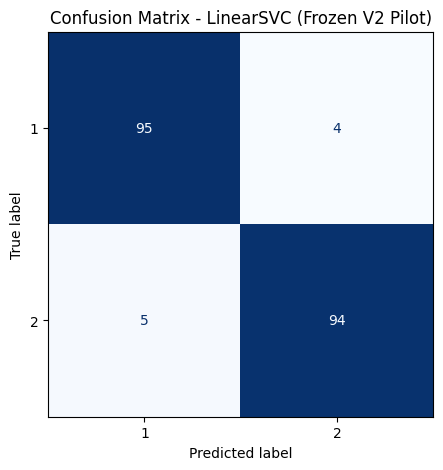

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load frozen windowed arrays
Xw = np.load('/content/drive/MyDrive/EMG_Project/processed/Xw_subject10.npy')
yw = np.load('/content/drive/MyDrive/EMG_Project/processed/yw_subject10.npy')

print("Windowed data:", Xw.shape, yw.shape)
print("Labels present:", np.unique(yw))

# Remove rest class
rest_label = 0
keep = yw != rest_label

X_seq = Xw[keep]   # shape: (N, 20, 10)
y_seq = yw[keep]

print("\nAfter removing rest:")
print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)
print("Classes:", np.unique(y_seq))

# Flatten windows for classical ML
X_feat = X_seq.reshape(X_seq.shape[0], -1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

print("\nTrain/Test:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Linear SVM baseline
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=1.0, max_iter=5000))
])

clf.fit(X_train, y_train)
preds = clf.predict(X_test)

acc = accuracy_score(y_test, preds)
macro_f1 = f1_score(y_test, preds, average="macro")

print("\nAccuracy:", acc)
print("Macro F1:", macro_f1)
print("\nClassification Report:\n")
print(classification_report(y_test, preds, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, preds, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - LinearSVC (Frozen V2 Pilot)")
plt.show()

In [31]:
results = {
    "model": "LinearSVC",
    "dataset": "Frozen Ninapro DB1 pilot (subject 10, labels 0/1/2)",
    "window_ms": 200,
    "step_ms": 100,
    "n_channels": 10,
    "window_shape": list(Xw.shape),
    "n_test_samples": int(len(y_test)),
    "classes_used_for_training": list(map(int, np.unique(y_seq))),
    "accuracy": float(acc),
    "macro_f1": float(macro_f1)
}

print(results)

with open('/content/drive/MyDrive/EMG_Project/results/v2_baseline_results.txt', 'w') as f:
    for k, v in results.items():
        f.write(f"{k}: {v}\n")

print("\nSaved results to:")
print('/content/drive/MyDrive/EMG_Project/results/v2_baseline_results.txt')

{'model': 'LinearSVC', 'dataset': 'Frozen Ninapro DB1 pilot (subject 10, labels 0/1/2)', 'window_ms': 200, 'step_ms': 100, 'n_channels': 10, 'window_shape': [1597, 20, 10], 'n_test_samples': 198, 'classes_used_for_training': [1, 2], 'accuracy': 0.9545454545454546, 'macro_f1': 0.9545442950794583}

Saved results to:
/content/drive/MyDrive/EMG_Project/results/v2_baseline_results.txt


# Adding Feature Extraction

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================
# 1. Load frozen windowed data
# =========================
Xw = np.load('/content/drive/MyDrive/EMG_Project/processed/Xw_subject10.npy')
yw = np.load('/content/drive/MyDrive/EMG_Project/processed/yw_subject10.npy')

print("Loaded windowed data:")
print("Xw:", Xw.shape)
print("yw:", yw.shape)
print("Unique labels:", np.unique(yw))

Loaded windowed data:
Xw: (1597, 20, 10)
yw: (1597,)
Unique labels: [0 1 2]


In [33]:
# =========================
# 2. Remove rest class
# =========================
rest_label = 0
keep = yw != rest_label

Xw_nonrest = Xw[keep]
yw_nonrest = yw[keep]

print("\nAfter removing rest:")
print("Xw_nonrest:", Xw_nonrest.shape)
print("yw_nonrest:", yw_nonrest.shape)
print("Classes:", np.unique(yw_nonrest))


After removing rest:
Xw_nonrest: (990, 20, 10)
yw_nonrest: (990,)
Classes: [1 2]


In [34]:
# =========================
# 3. Handcrafted feature extraction
# =========================
def rms(x):
    return np.sqrt(np.mean(x ** 2, axis=0))

def mav(x):
    return np.mean(np.abs(x), axis=0)

def wl(x):
    return np.sum(np.abs(np.diff(x, axis=0)), axis=0)

def zc(x, threshold=1e-4):
    s1 = x[:-1]
    s2 = x[1:]
    return np.sum(((s1 * s2) < 0) & (np.abs(s1 - s2) > threshold), axis=0)

def ssc(x, threshold=1e-4):
    x1 = x[:-2]
    x2 = x[1:-1]
    x3 = x[2:]
    return np.sum(
        (((x2 - x1) * (x2 - x3)) > 0) &
        ((np.abs(x2 - x1) > threshold) | (np.abs(x2 - x3) > threshold)),
        axis=0
    )

def extract_features(X_windows):
    feats = []
    for w in X_windows:
        f = np.concatenate([
            rms(w),
            mav(w),
            wl(w),
            zc(w),
            ssc(w)
        ])
        feats.append(f)
    return np.array(feats, dtype=np.float32)

F = extract_features(Xw_nonrest)

print("\nFeature matrix:")
print("F:", F.shape)


Feature matrix:
F: (990, 50)


In [35]:
# =========================
# 4. Train / test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    F, yw_nonrest, test_size=0.2, random_state=42, stratify=yw_nonrest
)

print("\nTrain/Test split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Train/Test split:
X_train: (792, 50)
X_test : (198, 50)
y_train: (792,)
y_test : (198,)


In [36]:
# =========================
# 5. Train classifier
# =========================
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=1.0, max_iter=5000))
])

clf.fit(X_train, y_train)
preds = clf.predict(X_test)

In [37]:
# =========================
# 6. Evaluation
# =========================
acc = accuracy_score(y_test, preds)
macro_f1 = f1_score(y_test, preds, average="macro")

print("\nFinal Version 2 Results")
print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("\nClassification Report:\n")
print(classification_report(y_test, preds, digits=4))




Final Version 2 Results
Accuracy: 0.9646464646464646
Macro F1: 0.9646383467278989

Classification Report:

              precision    recall  f1-score   support

           1     0.9792    0.9495    0.9641        99
           2     0.9510    0.9798    0.9652        99

    accuracy                         0.9646       198
   macro avg     0.9651    0.9646    0.9646       198
weighted avg     0.9651    0.9646    0.9646       198



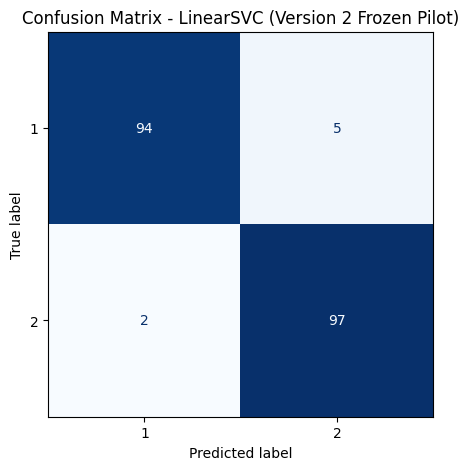

In [38]:
# =========================
# 7. Confusion matrix
# =========================
labels_sorted = np.unique(y_test)
cm = confusion_matrix(y_test, preds, labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - LinearSVC (Version 2 Frozen Pilot)")
plt.show()